# Example showing how to enable slack variables on import/export constraints

Slack variables can be used in situations where we do not know beforehand whether a problem is feasible, and if it is not feasible, we would like the solver to return a solution and be able to interrogate by how much the relevant constraints were violated. We do this by introducing slack variables into the relevant constraints and applying a large cost to the maximum slack value.

# Create a simple example
## We create a system where uncurtailable solar is fed through a connection point that has an export constraint.


In [1]:
import numpy as np
from echo.echo_models import *
from echo.echo_optimiser import *
from echo.objectives import *

time_periods = 96  # total number of intervals
interval_duration = 15  # Duration in mins of each interval
expansion_periods = 1  # Number of planning intervals - in echo V1, set to 1 always

pv_array = 2 * np.array(
    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.05, 0.23, 0.52,
     0.74, 0.71, 0.63, 0.68, 0.97, 0.01, 0.52, 0.83, 0.83, 0.79, 1.22, 1.36, 1.27, 1.42, 1.97, 2.56, 2.91, 3.24,
     3.8, 4.3, 4.62, 4.84, 4.6, 4.17, 3.77, 3.76, 3.38, 2.64, 1.96, 1.76, 1.85, 2.4, 3.82, 5.13, 4.97, 5.02, 5.43,
     5.32, 3.56, 1.75, 1.43, 1.65, 1.69, 2.3, 2.71, 2.41, 2.63, 2.6, 1.9, 0.78, 0.13, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
     0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

pv_array *= -1  # use positive load convention, so solar gen is negative

system = OptimisationGraph()
grid = Node()  # create node representing upstream grid
grid.add_electrical_ports_from_list(['grid'])

inverter = Inverter(max_import=None,
                    max_export=None,
                    dc_ac_efficiency=1,
                    ac_dc_efficiency=1)

inverter.add_ac_port('inv')  # add a port with name 'inv' that is used to connect upstream/ac side
inverter.add_dc_port('pv')  # add a port with name 'pv' for us to connect the pv node into


# create a node for the solar
solar = Node()
solar_port = ElectricalGeneration()  # create an electrical generation object
solar_port.curtailable = False  # set whether this can be curtailed or not
solar_port.add_generation_profile_from_array(pv_array, expansion_periods)
solar.ports['pv'] = solar_port  # add the solar port to the dictionary of node ports

system.add_node_obj([grid, inverter, solar])  # nodes can be added one by one or as a list

# Add edges to graph
system.connect_ports_and_create_edge(grid.ports['grid'], inverter.ports['inv'])
system.connect_ports_and_create_edge(inverter.ports['pv'], solar.ports['pv'])

## Set an export constraint on the grid connection port
We must be careful to pick the correct port here, so that we can get the import/export constraint correct.
Let's pick the inverter port that connects to the grid. We want to apply an export constraint, so we set `max_export` to our limit (-5), and leave `max_import=None`. Note that the export constraint value must be negative to adhere to positive load convention.

Alternatively, you could apply the same constraint on the grid node port that connects to the inverter. In this case, we would specify `max_export=None`, and `max_import=5`.

We can set the flow constraint by using `.set_flow_constraint()`, and also enable a slack variable on this constraint.

In [2]:
constrained_port = inverter.ports['inv']  # get the port object
constrained_port.set_flow_constraints(max_import=None, max_export=-5., slack=True)  # set a flow constraint

### Run the optimisation

In [3]:
# Invoke the optimiser
optimiser = EchoOptimiser(interval_duration=interval_duration,
                          number_of_intervals=time_periods,
                          number_of_expansion_intervals=expansion_periods,
                          discount_rate=0,
                          ES=system,
                          objective_set=None,
                          optimiser_engine='cplex')

# Optimise
optimiser.optimise()

### Look at results
The optimiser will create an indexed slack variable, which equals the slack taken up at each time interval.

It also creates a max slack variable, which equals the maximum slack over all optimisation time periods.

If there is an import and export constraint, echo will create a separate import slack variable and export slack variable.

In this case, because we only set an export constraint, we will only have an export slack variable.

We can look at this variable and see that in the middle of the day when solar generation is high and uncurtailable, we run into the export constraint of 5 kW, and the slack variable `.export_slack` has a non-zero value. We can see the maximum violation, given by  `.max_export_slack`.

In [5]:
inverter_output = optimiser.values(constrained_port.port_name)
slack = optimiser.values(constrained_port.export_slack)
max_slack = optimiser.values(constrained_port.export_slack_max)
print('Inverter output:\n', inverter_output)
print('Export slack:\n', slack)
print('Max export slack:\n', max_slack)

Inverter output:
 [  0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
   0.     0.     0.     0.     0.     0.     0.     0.    -0.1   -0.46
  -1.04  -1.48  -1.42  -1.26  -1.36  -1.94  -0.02  -1.04  -1.66  -1.66
  -1.58  -2.44  -2.72  -2.54  -2.84  -3.94  -5.12  -5.82  -6.48  -7.6
  -8.6   -9.24  -9.68  -9.2   -8.34  -7.54  -7.52  -6.76  -5.28  -3.92
  -3.52  -3.7   -4.8   -7.64 -10.26  -9.94 -10.04 -10.86 -10.64  -7.12
  -3.5   -2.86  -3.3   -3.38  -4.6   -5.42  -4.82  -5.26  -5.2   -3.8
  -1.56  -0.26   0.     0.     0.     0.     0.     0.     0.     0.
   0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
   0.     0.     0.     0.     0.     0.  ]
Export slack:
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.12 0.82 1.48 2.6  3.6  4.24
 4.68 4.2  3.34 2.54 2.52 1.76 0.28 0.   0.   0.   0.   2.64 5.26 4.94
 5.04 5.86 5

## Plot results
Plot the data from above

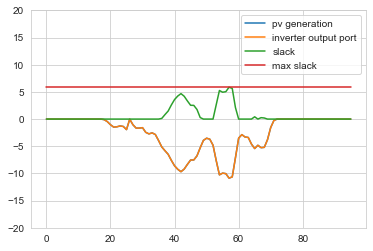

In [14]:
plt.plot(pv_array, label='pv generation')
plt.plot(inverter_output, label='inverter output port')
plt.plot(slack, label='slack')
plt.plot([max_slack]*time_periods, label='max slack')
plt.legend()
plt.ylim([-20,20])
plt.show()